In [5]:
# ==========================================
# 📦 IMPORT LIBRARIES
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [6]:
# ==========================================
# 📂 LOAD IMDB DATASET
# ==========================================
max_words = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_words)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (25000,)
Test shape: (25000,)


In [7]:
# ==========================================
# 🔤 PADDING
# ==========================================
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [8]:
# ==========================================
# 🧠 LSTM MODEL
# ==========================================
model = Sequential([
    Embedding(max_words, 128),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

2026-04-10 18:04:32.092326: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ==========================================
# 🚀 TRAINING
# ==========================================
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 210ms/step - accuracy: 0.7201 - loss: 0.5208 - val_accuracy: 0.8652 - val_loss: 0.3328
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 66s 187ms/step - accuracy: 0.8964 - loss: 0.2606 - val_accuracy: 0.8576 - val_loss: 0.3224
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 62s 175ms/step - accuracy: 0.9364 - loss: 0.1737 - val_accuracy: 0.8668 - val_loss: 0.3409
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 0.9526 - loss: 0.1318 - val_accuracy: 0.8624 - val_loss: 0.3684
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 72s 204ms/step - accuracy: 0.9665 - loss: 0.0973 - val_accuracy: 0.8612 - val_loss: 0.4251


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


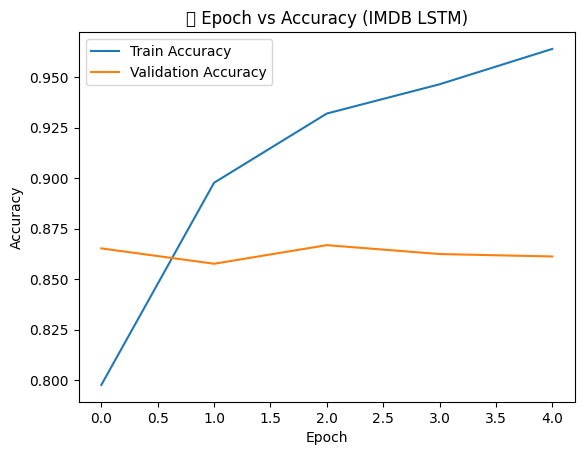

In [10]:
# ==========================================
# 📈 EPOCH vs ACCURACY
# ==========================================
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('📊 Epoch vs Accuracy (IMDB LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

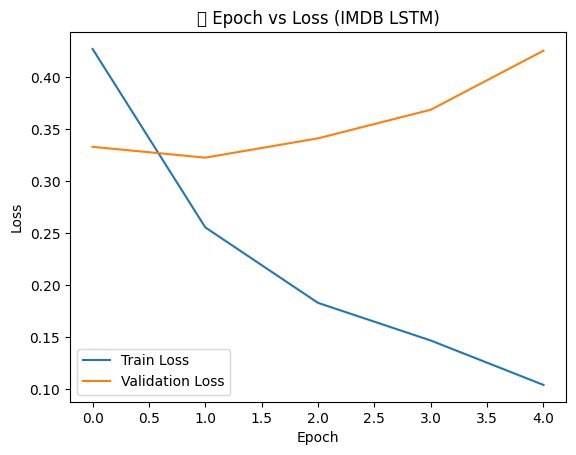

In [11]:
# ==========================================
# 📉 EPOCH vs LOSS
# ==========================================
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('📊 Epoch vs Loss (IMDB LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [12]:
# ==========================================
# 📊 MODEL EVALUATION
# ==========================================
preds = model.predict(X_test)
preds = (preds > 0.5).astype(int).flatten()

print("Accuracy:", accuracy_score(y_test, preds))

782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step
Accuracy: 0.85764


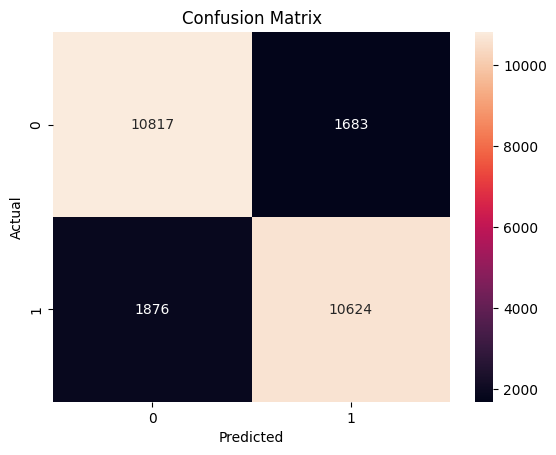

In [13]:
# ==========================================
# 🔍 CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
# ==========================================
# 📄 CLASSIFICATION REPORT
# ==========================================
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86     12500
           1       0.86      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [23]:
word_index = imdb.get_word_index()

def predict_review(text):
    words = text.lower().split()


    seq = [word_index.get(w, 2) + 3 for w in words]

    seq = pad_sequences([seq], maxlen=max_len)

    pred = model.predict(seq)[0][0]

    return "Positive" if pred > 0.5 else "Negative"

**🚀 Testing model with real-time tweets...**

In [25]:
# ==========================================
# 🧪 TEST MODEL (SINGLE INPUT)
# ==========================================
print("🚀 Testing model with real-time Reviews...")
review = input("Enter review: ")

result = predict_review(review)

print("Sentiment:", result)

🚀 Testing model with real-time Reviews...


Enter review:  This movie was very boring and waste of time.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Sentiment: Negative
